#Content

* [1. Introduction](#intro)
* [2. Initialisation](#ini)
* [3. Upload Data](#uploaddata)
* [4. Exploratory Data Analysis (EDA)](#eda)
* [5. Model for each dataset (RMSE and average reserve volume)](#rmse)

# 1.Introduction <a id='intro'></a>

The oil extraction company OilyGiant seeks to identify the best locations to open 200 new oil wells, based on existing wells in three different regions, taking into account crude oil quality and reserve volume.

To achieve this, a model will be developed to predict the reserve volume of new wells, allowing the selection of those with the highest values in order to maximize total profit while minimizing potential risk (criterion: no more than 2.5% loss). The project involves investing 100 million dollars in one of these three regions.

# 2.Initialisation <a id='intro'></a>

In [1]:
# Loading libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample
import random

import pandas as pd
import numpy as np

# 3.Upload Data <a id='uploaddata'></a>

In [3]:
geo_0 = pd.read_csv('geo_data_0.csv')
geo_1 = pd.read_csv('geo_data_1.csv')
geo_2 = pd.read_csv('geo_data_2.csv')

# 4.Exploratory Data Analysis (EDA) <a id='eda'></a>

In [ ]:
geo_0

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647
...,...,...,...,...,...
99995,DLsed,0.971957,0.370953,6.075346,110.744026
99996,QKivN,1.392429,-0.382606,1.273912,122.346843
99997,3rnvd,1.029585,0.018787,-1.348308,64.375443
99998,7kl59,0.998163,-0.528582,1.583869,74.040764


In [ ]:
geo_1

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305
...,...,...,...,...,...
99995,QywKC,9.535637,-6.878139,1.998296,53.906522
99996,ptvty,-10.160631,-12.558096,5.005581,137.945408
99997,09gWa,-7.378891,-3.084104,4.998651,137.945408
99998,rqwUm,0.665714,-6.152593,1.000146,30.132364


In [ ]:
geo_2

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746
...,...,...,...,...,...
99995,4GxBu,-1.777037,1.125220,6.263374,172.327046
99996,YKFjq,-1.261523,-0.894828,2.524545,138.748846
99997,tKPY3,-1.199934,-2.957637,5.219411,157.080080
99998,nmxp2,-2.419896,2.417221,-5.548444,51.795253


**Glossary of datasets:**

- id: unique oil well identifier
- f0, f1, f2: crude oil quality (their specific meaning is not important, but the characteristics themselves are significant)
- product: volume of reserves in the oil well (thousands of barrels).

In [4]:
geo_0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [5]:
geo_0.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


In [6]:
#Checking duplicate data in geo_0
duplicados = geo_0.duplicated()
cantidad_duplicados = duplicados.sum()
cantidad_duplicados # Finally, we check the number of duplicate rows in 'geo_0'


np.int64(0)

In [7]:
geo_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [8]:
geo_1.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


In [10]:
#Checking duplicate data in geo_1
duplicados = geo_1.duplicated()
cantidad_duplicados = duplicados.sum()
cantidad_duplicados # Finally, we check the number of duplicate rows in 'geo_1'


np.int64(0)

In [11]:
geo_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [12]:
geo_2.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


In [13]:
#Checking duplicate data in geo_2
duplicados = geo_2.duplicated()
cantidad_duplicados = duplicados.sum()
cantidad_duplicados # Finally, we check the number of duplicate rows in 'geo_2'


np.int64(0)

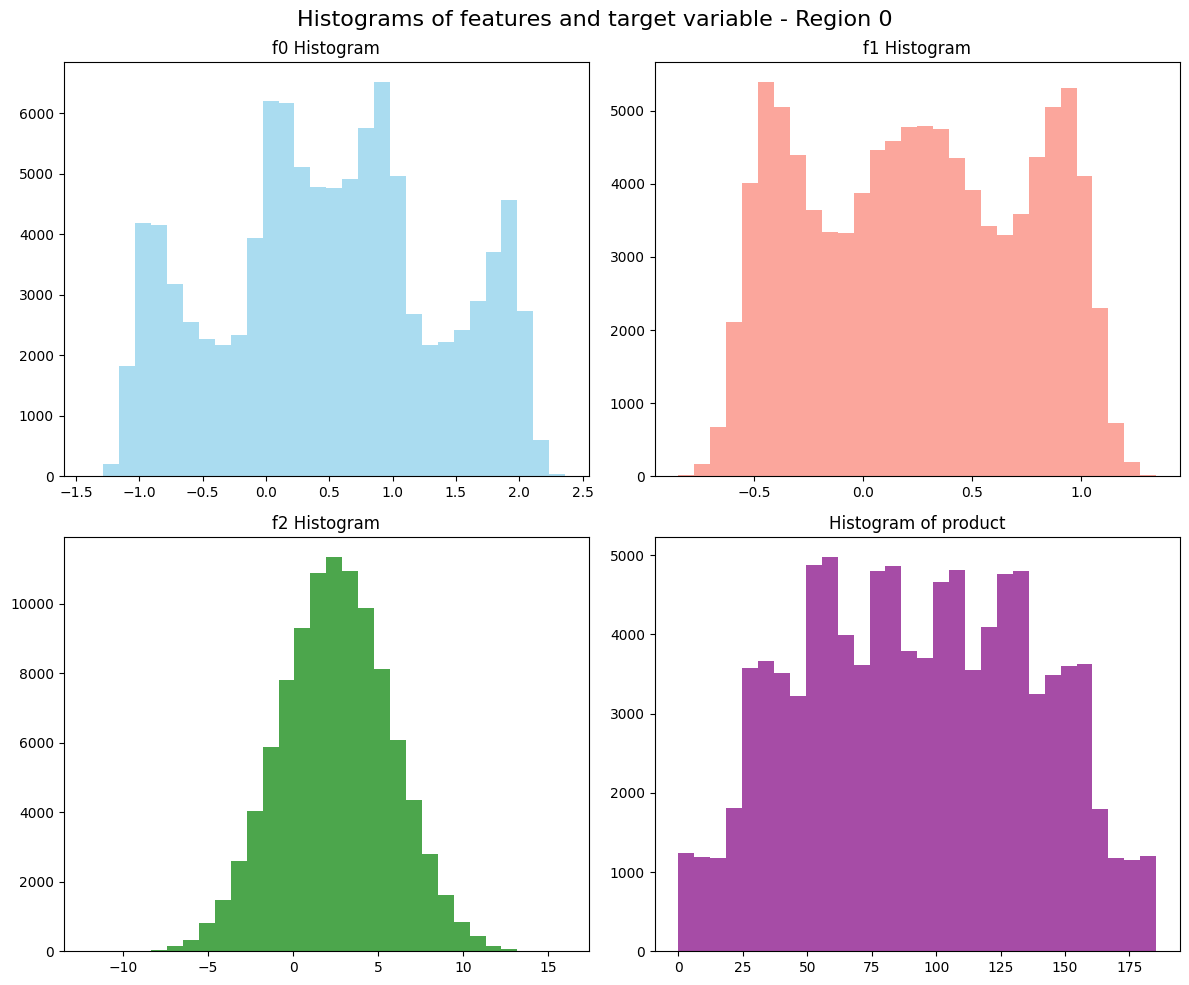

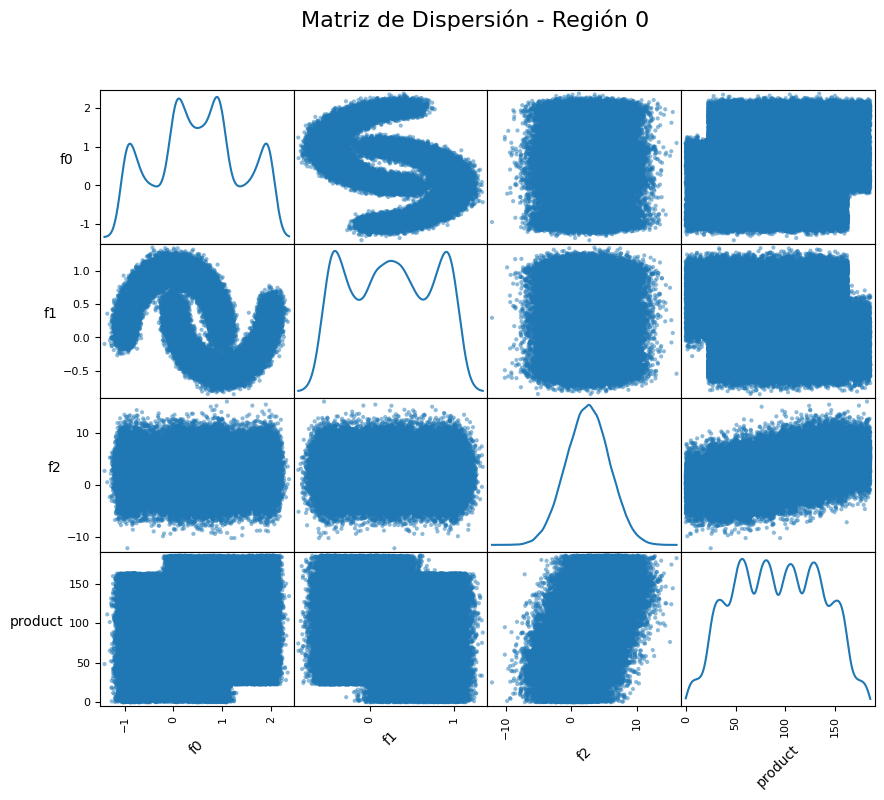

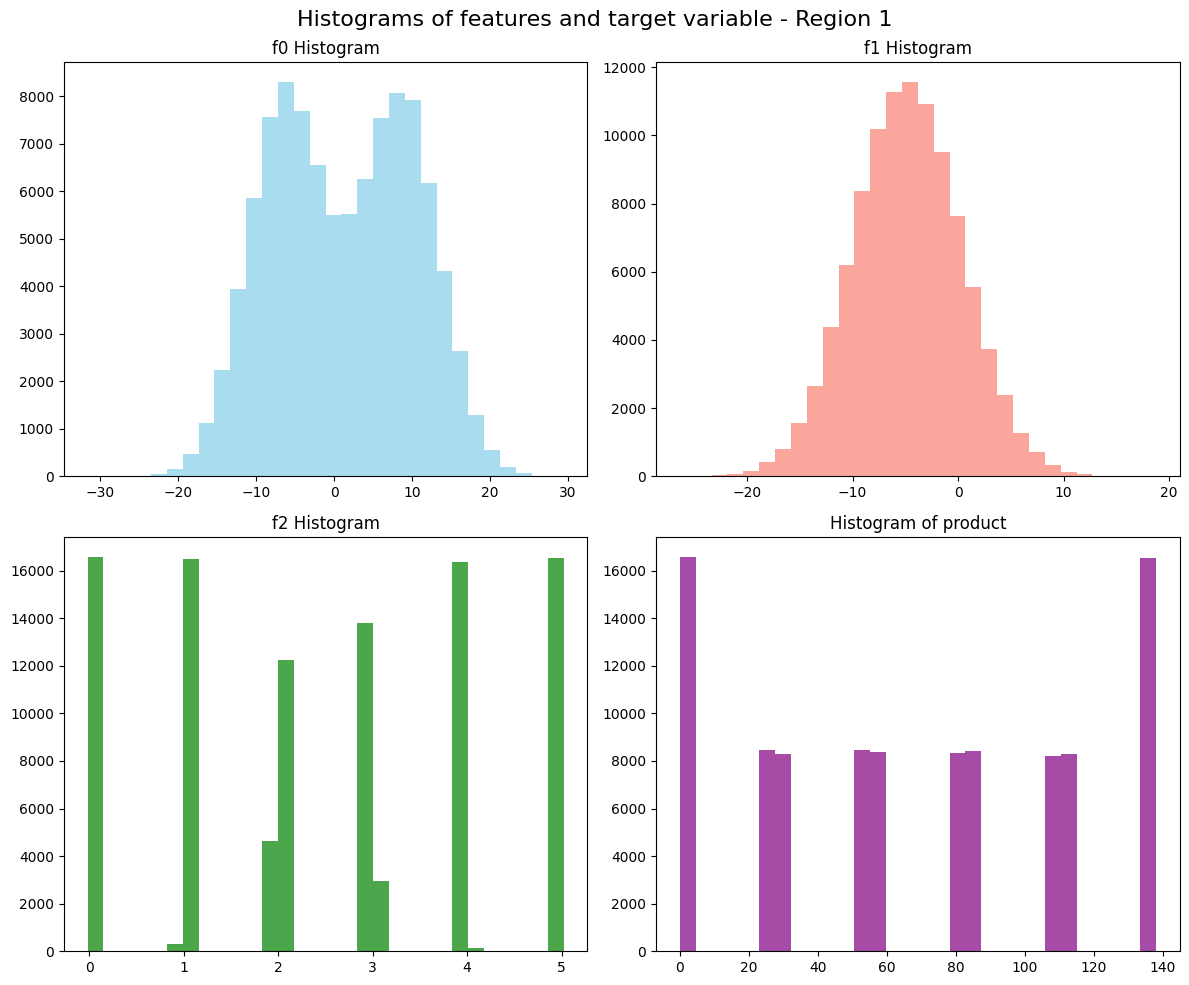

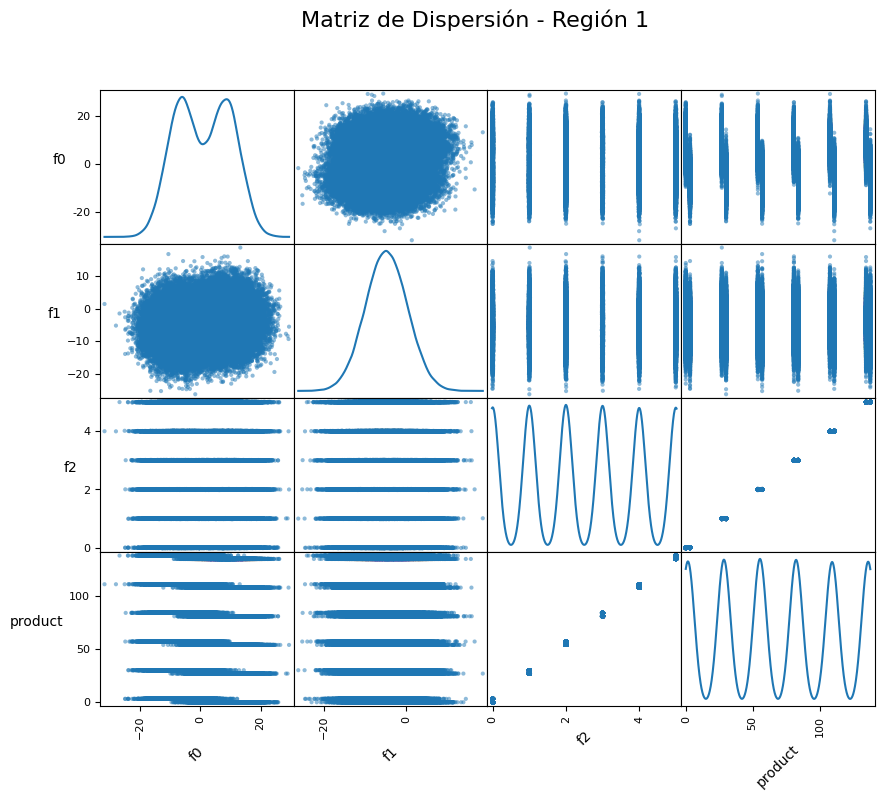

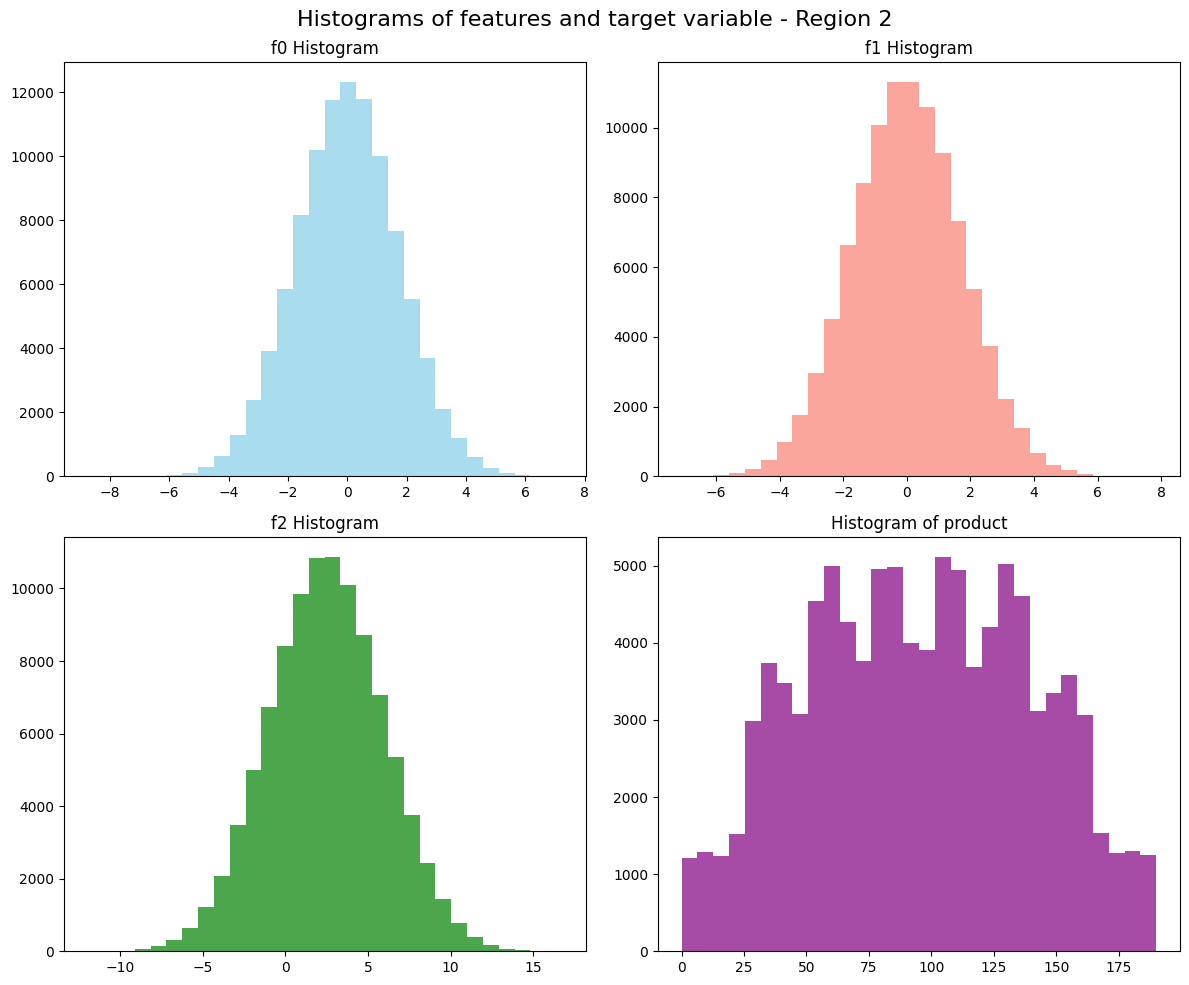

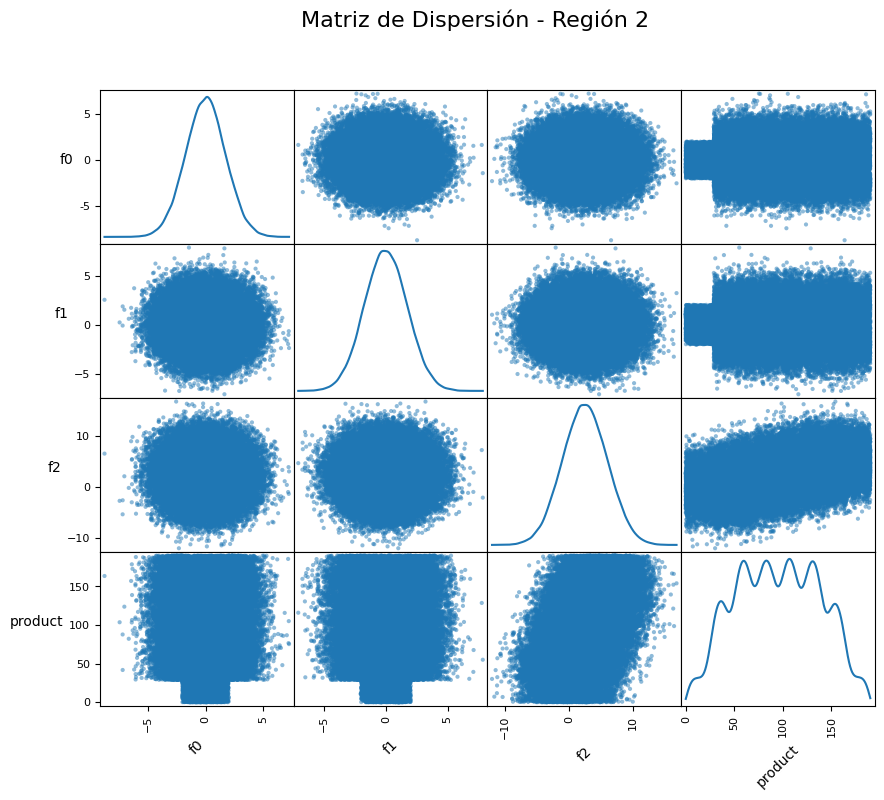

In [15]:
# Define the function to visualise histograms and scatter plots
def visualize_data(df, region):
# Histograms of the features and the target variable
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
    axes[0, 0].hist(df['f0'], bins=30, color='skyblue', alpha=0.7)
    axes[0, 0].set_title('f0 Histogram')
    axes[0, 1].hist(df['f1'], bins=30, color='salmon', alpha=0.7)
    axes[0, 1].set_title('f1 Histogram')
    axes[1, 0].hist(df['f2'], bins=30, color='green', alpha=0.7)
    axes[1, 0].set_title('f2 Histogram')
    axes[1, 1].hist(df['product'], bins=30, color='purple', alpha=0.7)
    axes[1, 1].set_title('Histogram of product')
    plt.suptitle(f'Histograms of features and target variable - Region {region}', fontsize=16)
    plt.tight_layout()
    plt.show()


# Define the function to display the scatter plot
def visualize_scatter_matrix(df, region):
    # Select only the features and the target variable
    features = ['f0', 'f1', 'f2', 'product']
    df_subset = df[features]

    # Create the scatter matrix
    scatter_matrix = pd.plotting.scatter_matrix(df_subset, figsize=(10, 8), diagonal='kde')

    # Adding a title
    plt.suptitle(f'Matriz de Dispersión - Región {region}', fontsize=16)

    # Adjust the layout to avoid overlaps
    for ax in scatter_matrix.ravel():
        ax.xaxis.label.set_rotation(45)
        ax.yaxis.label.set_rotation(0)
        ax.yaxis.label.set_ha('right')

    # Display the scatter matrix
    plt.show()

# Visualise the data for each region
visualize_data(geo_0, 0)
visualize_scatter_matrix(geo_0, 0)
visualize_data(geo_1, 1)
visualize_scatter_matrix(geo_1, 1)
visualize_data(geo_2, 2)
visualize_scatter_matrix(geo_2, 2)



From the above information, we can conclude the following:

- Each dataset contains a total of 10,000 rows.

- There are no missing values in the datasets.

- We do not have additional background information about the variables f0, f1, and f2, so we assume their maximum and minimum value ranges are correct.

- The data types for each variable (object and float) are correct across all datasets.

- There are no duplicate records.

**Data distribution and correlation prior to modeling:**

- For Region 0: variables f0 and f1 show similar distributions, while f2 has a more symmetric distribution resembling a Gaussian bell curve.

- Regarding correlation in Region 0: variable f2 shows a slight positive correlation with the target variable, while f0 and f1 have almost no correlation.

- For Region 1: variables f0 and f1 display symmetric distributions, with the main difference being that f0 shows fewer data points around the value 0. Variable f2 behaves similarly to a discrete variable, with a distribution pattern resembling that of f0.

- Regarding correlation in Region 1: there is a directly proportional correlation between the target variable product and f2, while the other variables show no significant correlation.

- For Region 2: all three variables exhibit fairly symmetric distributions, closely resembling a Gaussian bell curve.

- Regarding correlation in Region 2: as in the previous cases, f2 shows a direct correlation with product, unlike f0 and f1.

# 5.Model for each dataset (RMSE and average reserve volume) <a id='rmse'></a>

Considerations or assumptions for this model:

- We will apply and assume a linear regression model (the rest are not sufficiently predictable).

In [18]:
# Function to calculate RMSE
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# List to store results
results = []

# Iterate over the datasets
for i, data in enumerate([geo_0, geo_1, geo_2], start=1):

    # Split dataset into features (x) and target (y)
    x = data[['f0', 'f1', 'f2']]
    y = data['product']

    # Split dataset into training and validation sets
    x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.25, random_state=12345)

    # Initialize and train the linear regression model
    model = LinearRegression()
    model.fit(x_train, y_train)

    # Make predictions on the validation set
    y_pred = model.predict(x_valid)

    # Calculate the mean predicted reserve volume
    mean_predicted_volume = y_pred.mean()

    # Calculate the model’s RMSE
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

    # Store results
    results.append({
        'dataset': f'Dataset {i}',
        'mean_predicted_volume': mean_predicted_volume,
        'rmse': rmse,
        'predictions': y_pred,
        'actual': y_valid
    })

    # Print results
    print(f"Mean predicted reserve volume for Dataset {i}: {mean_predicted_volume}")
    print(f"Model RMSE for Dataset {i}: {rmse}\n")

# Save results into a DataFrame
results_df = pd.DataFrame(results)
results_df


Mean predicted reserve volume for Dataset 1: 92.59256778438035
Model RMSE for Dataset 1: 37.5794217150813

Mean predicted reserve volume for Dataset 2: 68.728546895446
Model RMSE for Dataset 2: 0.893099286775617

Mean predicted reserve volume for Dataset 3: 94.96504596800489
Model RMSE for Dataset 3: 40.02970873393434



,dataset,mean_predicted_volume,rmse,predictions,actual
0,Dataset 1,92.592568,37.579422,"[95.8949518459208, 77.57258260954838, 77.89263...",71751 10.038645 80493 114.551489 2655 ...
1,Dataset 2,68.728547,0.893099,"[82.66331364514757, 54.431786156149215, 29.748...",71751 80.859783 80493 53.906522 2655 ...
2,Dataset 3,94.965046,40.029709,"[93.59963303173876, 75.10515853556217, 90.0668...",71751 61.212375 80493 41.850118 2655 ...


**Preliminary Conclusions:**

Although Dataset 2 has the lowest RMSE, it is important to consider more than just RMSE when selecting the best model. For instance, the mean predicted reserve volume in Dataset 2 is significantly lower than in the other datasets. Therefore, both RMSE and the mean predicted reserve volume should be taken into account when determining which model performs best.

Next, we will include the profit ($) variable for the selection of the optimal model.

## 5.1 Model of the region with the highest profit margin

### 5.1.1 Definition of parameters for obtaining profit

**Conditions:**

- During exploration of each region, 500 points are studied, with the top 200 points selected for profit calculation.

- The budget for developing 200 oil wells is 100 million USD.

- One barrel of crude generates 4.5 USD in revenue. The revenue for one unit of product is 4,500 USD (since reserve volumes are expressed in thousands of barrels).

- After risk assessment, only regions with a loss risk below 2.5% will be retained. Among those meeting the criteria, the region with the highest average profit will be selected.

In [19]:
# 1) Store the parameters needed for the calculations in separate variables
investment_per_well = 500000  # Investment per oil well in USD (100M/200 wells)
min_production_value = 500000  # Minimum production value per well in USD
mean_price_per_unit = 4500  # 4500 USD per barrel

# 2) Compare the minimum reserve requirement with the average reserves in each region
# Calculate the minimum number of units a well must produce to reach the minimum production value
min_production_units = min_production_value / mean_price_per_unit

# Calculate the average reserves in each region
mean_reserves_per_region = [geo_0['product'].mean(), geo_1['product'].mean(), geo_2['product'].mean()]

# 3) Present conclusions on how to prepare the next step for profit calculation
for i, mean_reserves in enumerate(mean_reserves_per_region):
    print(f"Region {i}:")
    print(f"Average reserves: {mean_reserves} units")
    print(f"Minimum reserves required to avoid losses: {min_production_units} units (thousands of barrels per well)")
    if mean_reserves >= min_production_units:
        print("The average reserves are sufficient to avoid losses.")
    else:
        print("The average reserves are insufficient to avoid losses.")
    print()


Region 0:
Average reserves: 92.50000000000001 units
Minimum reserves required to avoid losses: 111.11111111111111 units (thousands of barrels per well)
The average reserves are insufficient to avoid losses.

Region 1:
Average reserves: 68.82500000000002 units
Minimum reserves required to avoid losses: 111.11111111111111 units (thousands of barrels per well)
The average reserves are insufficient to avoid losses.

Region 2:
Average reserves: 95.00000000000004 units
Minimum reserves required to avoid losses: 111.11111111111111 units (thousands of barrels per well)
The average reserves are insufficient to avoid losses.



From the above, we can conclude that:

- Since the average reserves in each region are lower than the minimum average reserves required to avoid losses, we can initially conclude that focusing on a single region to exploit the wells would not be profitable.

- This is based on the assumption that the USD 100 million investment is distributed evenly across the 200 new wells.

- It will be necessary to evaluate each well individually across the different regions to identify which ones are potentially and actually profitable according to the criterion mentioned above.

- Regarding the calculation of profits, two key aspects must be considered:

- The average production per oil well, specifically the volume that exceeds the minimum number of barrel units per well required to avoid losses.

- The market price of oil, which will allow us to determine the average price per barrel in USD and thus estimate the expected revenue per unit of product produced.

### 5.1.2 Benefit/risk – best 200 wells

In [22]:
# We calculate the potential profit and select the 200 best wells for each region.
def calculate_profit(df_region):
    # We obtain all predictions (sum) of reserve volume (applicable for each region).
    all_predictions = df_region['predictions'].sum()

    # We select the 200 highest predictions (applicable for each region)
    top_200_predictions = sorted(all_predictions, reverse=True)[:200]

    # We calculate the sum of the predictions for the top 200 wells (target volume)
    volumen_reservas = sum(top_200_predictions)

    # Calculate the potential profit from the top 200 wells
    ganancia_potencial = volumen_reservas * 4500  # Revenue per barrel * reserve volume

    return ganancia_potencial, top_200_predictions

# We calculate the potential profit and select the top 200 wells for each region
ganancia_region_0, top_200_pozos_region_0 = calculate_profit(results_df[results_df['dataset'] == 'Dataset 1'])
ganancia_region_1, top_200_pozos_region_1 = calculate_profit(results_df[results_df['dataset'] == 'Dataset 2'])
ganancia_region_2, top_200_pozos_region_2 = calculate_profit(results_df[results_df['dataset'] == 'Dataset 3'])

# Potential profits by region
print("Potential profit from the 200 best wells for Region 0:", ganancia_region_0)
print("Potential profit from the 200 best wells for Region 1:", ganancia_region_1)
print("Potential profit from the 200 best wells for Region 2:", ganancia_region_2)

# We compare potential profits and propose the best region for oil well development.
ganancias = [ganancia_region_0, ganancia_region_1, ganancia_region_2]
regiones = ['Región 0', 'Región 1', 'Región 2']

region_seleccionada = regiones[np.argmax(ganancias)] #We found the index for the region with the highest earnings on the earnings list.
print("\nThe region selected for oil well development is:", region_seleccionada)


Potential profit from the 200 best wells for Region 0: 139960488.77465132
Potential profit from the 200 best wells for Region 1: 124857120.51973544
Potential profit from the 200 best wells for Region 2: 133217543.96243262

The region selected for oil well development is: Región 0


As a preliminary conclusion, we can see that: considering only the potential profit using the 200 highest predictions for each region, region 0 has the advantage for oil well development.

We will now proceed to calculate the benefits and risks for each region using the bootstrapping method for a 95% confidence interval. We will use a random sample of 500 validation points for each region, selecting the 200 best from this sample and then calculating the potential gain associated with these 200 best points.

We will consider omitting those regions with a risk of loss greater than 2.5%.

In [23]:
# Function to calculate the benefits and risks for each region
def calcular_beneficios_y_riesgos(predictions):
    # List for storing results by region
    resultados = []

    # We perform bootstrapping with 1000 samples.
    for _ in range(1000):
        # We randomly select 500 validation points with replacement.
        sampled_data = np.random.choice(predictions, size=500, replace=True)

        # Sort the predictions and select the top 200
        top_200_predictions = np.sort(sampled_data)[::-1][:200]

        # Calculate the potential profit of the top 200 wells
        volumen_reservas = sum(top_200_predictions)
        ganancia_potencial = volumen_reservas * mean_price_per_unit

        # We store the potential profit in the results list.
        resultados.append(ganancia_potencial)


    # Calculating the average profit
    beneficio_promedio = np.mean(resultados)

    # We calculate the 95% confidence interval.
    intervalo_confianza_95 = np.percentile(resultados, [2.5, 97.5])

    # We calculate the risk of loss (probability of obtaining a negative return).
    riesgo_perdidas = np.mean(np.array(resultados) < 0) * 100

    return beneficio_promedio, intervalo_confianza_95, riesgo_perdidas, resultados

# We calculate the benefits and risks for each region.
beneficio_promedio_region_0, intervalo_confianza_95_region_0, riesgo_perdidas_region_0, ganancias_region_0 = calcular_beneficios_y_riesgos(results_df[results_df['dataset'] == 'Dataset 1']['predictions'].iloc[0])
beneficio_promedio_region_1, intervalo_confianza_95_region_1, riesgo_perdidas_region_1, ganancias_region_1 = calcular_beneficios_y_riesgos(results_df[results_df['dataset'] == 'Dataset 2']['predictions'].iloc[0])
beneficio_promedio_region_2, intervalo_confianza_95_region_2, riesgo_perdidas_region_2, ganancias_region_2 = calcular_beneficios_y_riesgos(results_df[results_df['dataset'] == 'Dataset 3']['predictions'].iloc[0])


print("Results for Region 0:")
print("Average profit:", beneficio_promedio_region_0)
print("Confidence Interval of 95%:", intervalo_confianza_95_region_0)
print("Risk of loss:", riesgo_perdidas_region_0, "%\n")

print("Results for Region 1:")
print("Average profit:", beneficio_promedio_region_1)
print("Confidence Interval of 95%:", intervalo_confianza_95_region_1)
print("Risk of loss:", riesgo_perdidas_region_1, "%\n")

print("Results for Region 2:")
print("Average profit", beneficio_promedio_region_2)
print("Confidence Interval of 95%:", intervalo_confianza_95_region_2)
print("Riesk of loss:", riesgo_perdidas_region_2, "%\n")

Results for Region 0:
Average profit: 103597581.5850989
Confidence Interval of 95%: [1.01311481e+08 1.05805524e+08]
Risk of loss: 0.0 %

Results for Region 1:
Average profit: 104538879.38124152
Confidence Interval of 95%: [1.00662598e+08 1.08367926e+08]
Risk of loss: 0.0 %

Results for Region 2:
Average profit 102734963.66604991
Confidence Interval of 95%: [1.00831623e+08 1.04658922e+08]
Riesk of loss: 0.0 %



###  5.1.3 Distribution of potential profit by region

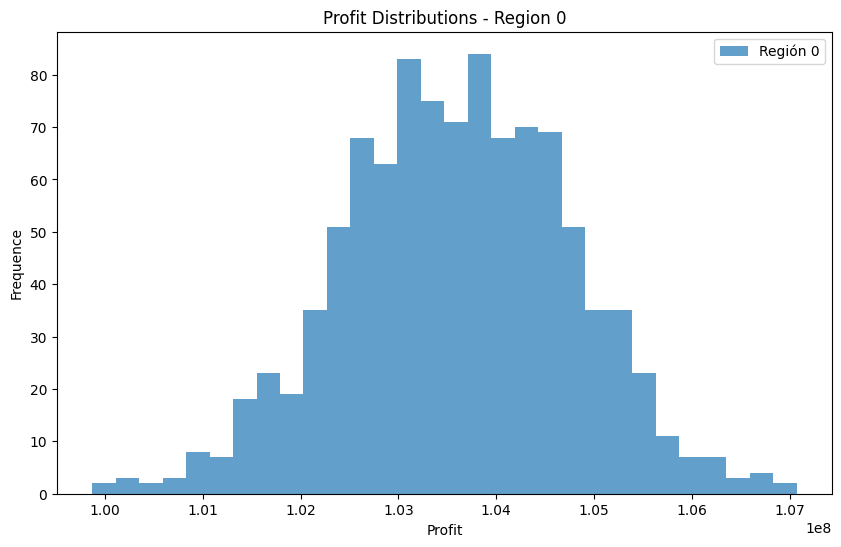

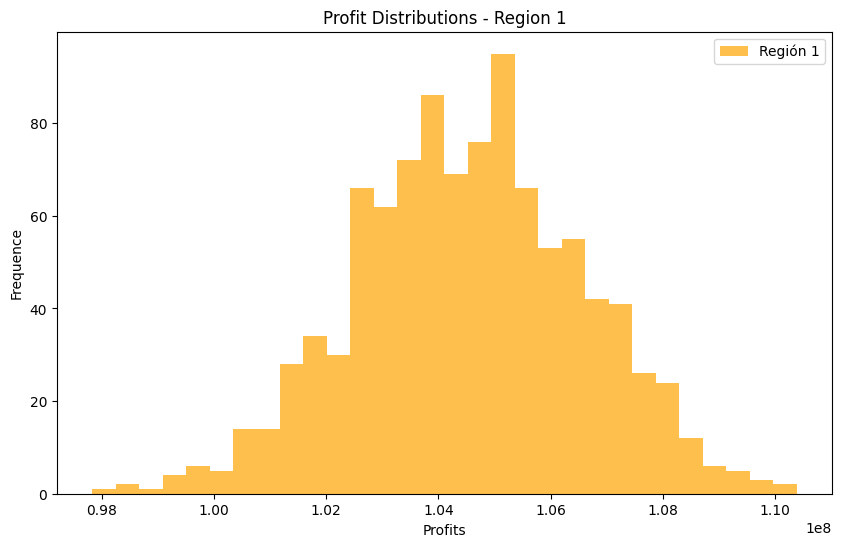

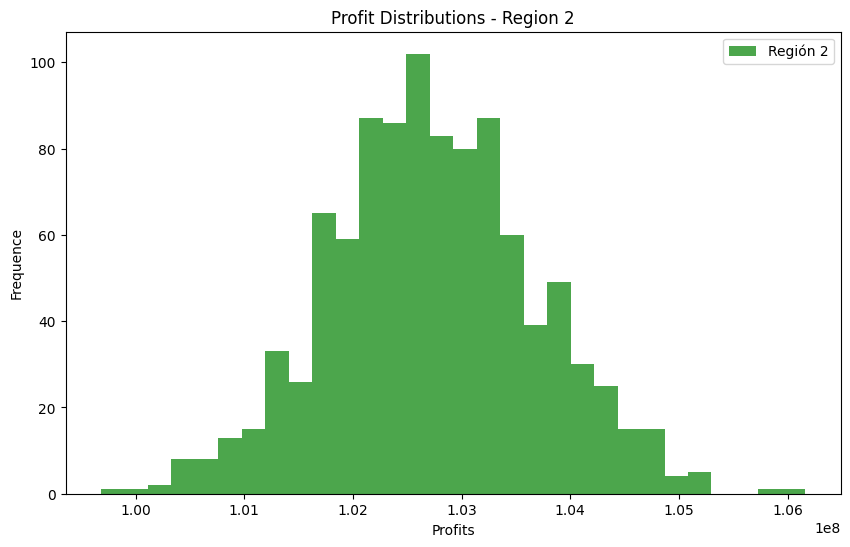

In [24]:
# We create histograms for the distribution of earnings for each region.
plt.figure(figsize=(10, 6))

# Region 0
plt.hist(ganancias_region_0, bins=30, alpha=0.7, label='Región 0')
plt.xlabel('Profit')
plt.ylabel('Frequence')
plt.title('Profit Distributions - Region 0')
plt.legend()
plt.show()

# Region 1
plt.figure(figsize=(10, 6))
plt.hist(ganancias_region_1, bins=30, alpha=0.7, color='orange', label='Región 1')
plt.xlabel('Profits')
plt.ylabel('Frequence')
plt.title('Profit Distributions - Region 1')
plt.legend()
plt.show()

# Region 2
plt.figure(figsize=(10, 6))
plt.hist(ganancias_region_2, bins=30, alpha=0.7, color='green', label='Región 2')
plt.xlabel('Profits')
plt.ylabel('Frequence')
plt.title('Profit Distributions - Region 2')
plt.legend()
plt.show()

**Preliminary Conclusion:**

In terms of profit and at the predictive level, it can be stated that all regions are potentially profitable for investors, since all of them exceed the \$ 100 million investment for the 200 wells. Among them, Region 1 shows a slightly higher risk-benefit margin compared to the other regions, with a potential profit of \$103,337,397 USD and a 0\% risk at a 95% confidence level.

This can be clearly seen in the histograms, which show that the profit distributions of all regions are above $100 million, with a greater concentration of data around \$102 million USD.

It should be noted that all regions display a relatively low deviation and a fairly similar distribution at the 95\% confidence level, making them all attractive investment options.

# 6.Conclusions

From the above, we can conclude that:

- All three regions have an attractive potential profit for investment, as anticipated in Section 5.2, when the project was evaluated considering only profits without applying the bootstrapping method.

- In all three regions, the estimated potential profits have a high level of accuracy according to the model, considering a 95% confidence level. The deviations are around 2 million USD.

- To increase precision in the analysis, the bootstrapping method with 95% confidence intervals was applied. We can assert that the best region for oil well exploitation is Region 1, with potential net profit ranges between [100,442,978 ; 108,602,518] USD, as it offers the highest cost-benefit compared to the other regions.

- Based on this, we can observe that the result obtained differs slightly from the initial expectation in Section 5.1, where Region 0 had the highest potential profit without considering bootstrapping or risk. In fact, the potential profit for Region 0 was overestimated at 139,960,489 USD.

- The risk of loss for each region is close to 0%, suggesting that it is unlikely that any investment in oil wells in the three regions would incur losses.